# PJME Hourly Load Forecasting: Prophet Model with CV & Tuning

### 🧭 Overview  
In this notebook, we train a Prophet model to forecast PJM’s hourly load.  
Building on the EDA in **analysis.ipynb**, we’ll clean out known hurricane‐period anomalies, run time‐series cross‐validation over long horizons (up to a year), and use Optuna to fine-tune model settings.  
The forecasts (and residuals) produced here form our baseline before incorporating XGBoost into the hybrid model.

---

### 📊 Purpose  
Build a standalone Prophet model that:  
- Captures large-scale trends and seasonal patterns (daily, weekly, yearly)  
- Handles holiday effects and smooths out hurricane-related dips  
- Uses time-based cross-validation to check performance over long forecast horizons (~1 year)

This model acts as a baseline and helps us see how well Prophet can capture the overall structure of the data—before we introduce XGBoost later to handle the smaller, more detailed variations.

---




## 📑 Table of Contents

1. [Setup & Imports](#setup--imports)  
2. [Data Loading](#data-loading)  
3. [Feature Engineering & Hurricane Cleaning](#feature-engineering--hurricane-cleaning)  
4. [Model Training & Evaluation Pipeline](#model-training--evaluation-pipeline)  

---

## 1️⃣ Setup & Imports <a id="setup--imports"></a>

In [5]:
import os
import json
import optuna
import plotly
import pickle
import joblib
import kaleido
import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from utils.data_utils import *
from utils.model_utils import *

import warnings
warnings.filterwarnings('ignore')

## 2️⃣ Data Loading <a id="data-loading"></a>

In [2]:
data_dir = 'data'
output_dir = 'output_prophet_II_v2'

df = load_data(f'{data_dir}/PJME_hourly.csv')


## 3️⃣ Feature Engineering & Hurricane Cleaning <a id="feature-engineering--hurricane-cleaning"></a>  

**Purpose:** Add calendar-based features (hour, weekday, month), identify holidays, and interpolate periods affected by hurricanes to reduce noise in the data.

In [3]:
# Apply feature engineering and drop missing values
df = create_features(df.dropna())

In [4]:
# Global split into training and test sets
full_train, test_set = split_train_test(df,'2015-01-01')

### Visualizing Hurricane-Related Outliers

To better understand the impact of extreme weather events, we visualize the PJM hourly load data during known hurricane periods. In particular, **Hurricane Sandy** hit the East Coast on **2012-10-29**, causing significant disruptions to energy demand across the region. Highlighting this period helps identify and confirm outlier behavior in the data, ensuring these anomalies are properly handled during model training and evaluation.

---

In [71]:
df_clean = df.copy()

hurricane_periods = pd.date_range('2012-10-29 00:00', '2012-11-01 00:00', freq='H')
mask = df_clean['ds'].isin(hurricane_periods) & (df_clean['y'] < 19000)
df_clean['is_hurricane'] = mask.astype(int)

print("Number of outliers masked", df_clean['is_hurricane'].sum())

Number of outliers masked 15


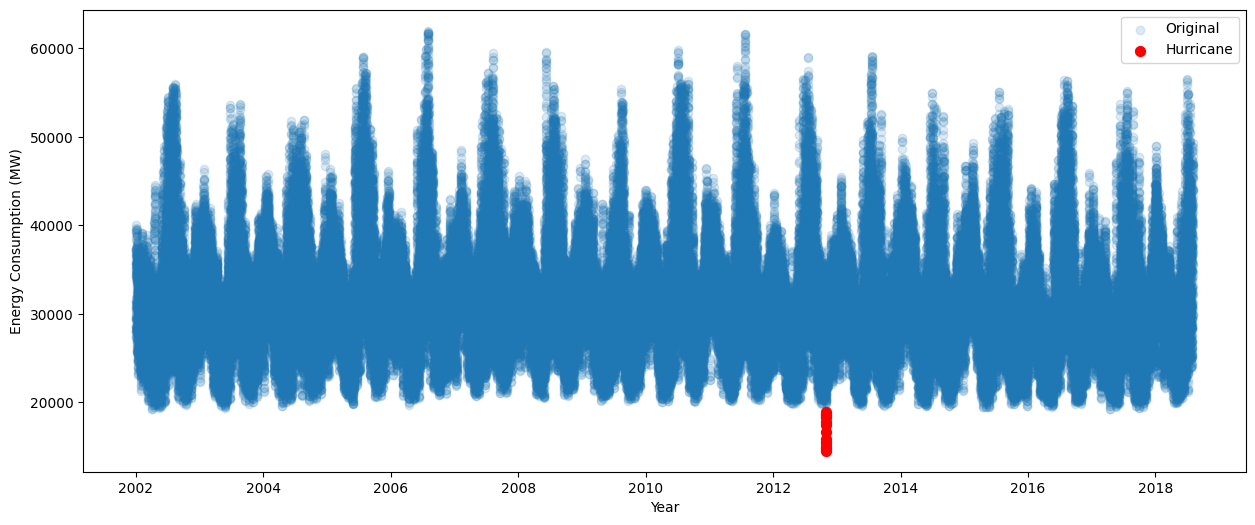

In [74]:
plt.figure(figsize=(15,6))
plt.scatter(df_clean['ds'], df_clean['y'], label='Original', alpha=0.15)
plt.scatter(df_clean[df_clean['is_hurricane']==1]['ds'], 
            df_clean[df_clean['is_hurricane']==1]['y'],
            color='red', s=50, label='Hurricane')
plt.legend()
plt.xlabel("Year")
plt.ylabel("Energy Consumption (MW)")
plt.show()

**Notes:**  
- For visualization, outliers are flagged as "hurricane" if they fall within the period from 2012-10-29 00:00 to 2012-11-01 00:00 **and** have `y < 19000`. These points are highlighted in red on the plot to illustrate the impact of Hurricane Sandy.

- The function used for data cleaning is `clean_train_data(trial_or_params, train_df)` from `data_utils.py`.

- Currently, this function detects and imputes outliers **across the entire time series**, not just within the hurricane-affected window. While this is a robust general approach, restricting outlier detection and imputation to only the hurricane-affected period could potentially yield better results, especially if hurricane events are the only known source of anomalies in the data.

In [ ]:
# def objective(trial):
#     """
#     Objective function to optimize Prophet model hyperparameters along with the cleaning parameters.

#     Uses cross-validation with specified settings and returns the mean MAPE.
#     """
#     # Clean the training data using hyperparameter suggestions from the trial
#     cleaned_train, hurricane_dates = clean_train_data(trial, full_train)
    
#     # Prophet hyperparameter suggestions from the trial (from previous trials)
#     prophet_params = {
#         'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.02, 0.09),
#         'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 1, 5.0),
#         'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 8, 12),
#         'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['multiplicative', 'additive']),
#         'yearly_seasonality': trial.suggest_int('yearly_seasonality', 6, 9)
#     }
    
#     # Initialize the Prophet model using the provided parameters and hurricane dates
#     model = Prophet(
#         **prophet_params,
#         holidays=hurricane_dates,
#         daily_seasonality=False,
#         weekly_seasonality=False
#         )
#     model.add_country_holidays('US')
    
#     # Fit the model on the cleaned training data.
#     try:
#         model.fit(cleaned_train)
#     except Exception as e:
#         print(f"Fitting failed: {str(e)}")
#         return 100.0  # Return a high error if the fitting fails
    
#     # Perform cross-validation to evaluate the model's performance
#     try:
#         df_cv = cross_validation(
#             model,
#             initial='730 days',
#             period='180 days',
#             horizon='365 days',
#             disable_tqdm=True,
#             parallel="processes"
#         )
#         df_p = performance_metrics(df_cv, rolling_window=1)
#         mape = df_p['mape'].mean()
#     except Exception as e:
#         print(f"Validation failed: {str(e)}")
#         mape = 100.0  # Penalize invalid configurations
    
#     return mape

# if __name__ == "__main__":
#     # Create an Optuna study to minimize MAPE
#     study = optuna.create_study(
#         direction='minimize',
#         sampler=optuna.samplers.TPESampler(seed=42)
#     )
    
#     # Optimize the objective function 
#     study.optimize(objective, n_trials=1, timeout=3600 * 1)
    
#     print(f"Best MAPE: {study.best_value * 100:.2f}%") # print(f"Best MAPE: {study.best_value * 100:.2f}%")
#     print("Best params:")
#     for key, value in study.best_params.items():
#         print(f"- {key}: {value}")

## 4️⃣ Model Training & Evaluation Pipeline <a id="model-training--evaluation-pipeline"></a>

This section walks through the full modeling workflow, where we:

- Combine all previous steps—feature engineering, data cleaning, and hurricane handling—into a single pipeline.
- Use Optuna to automatically tune Prophet model and data cleaning hyperparameters.
- Apply time-based cross-validation to evaluate forecasting performance.
- Save the best model and configuration for future use.

---

### Hyperparameter Tuning & Training Pipeline

**Purpose:**  
- Define the Optuna objective function to tune Prophet model hyperparameters and data cleaning parameters.
- Set up the training, cross-validation, and evaluation logic for each Optuna trial.
- Track and store results for each trial to identify the best-performing configuration.

---

**Context:**  
- This subsection implements the core optimization loop: each Optuna trial proposes a set of parameters, cleans the data, fits the Prophet model, and evaluates performance using cross-validation.
- The cross-validation horizon is set to 365 days mainly to reduce time and computational load. In practice, the final model is evaluated and used for shorter, more realistic horizons.
- This pipeline establishes a Prophet-only baseline; XGBoost will be incorporated later to further improve performance

---

In [75]:
results = {}

def objective(trial):
    """
    Objective function to optimize Prophet model hyperparameters along with the cleaning parameters.

    Uses cross-validation with specified settings and returns the mean MAPE.
    """
    # Clean the training data using hyperparameter suggestions from the trial
    cleaned_train, hurricane_dates = clean_train_data(trial, full_train)
    
    # Prophet hyperparameter suggestions from the trial
    prophet_params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.05, log=True),
        'changepoint_range': trial.suggest_float('changepoint_range', 0.3, 0.9),
        'n_changepoints': trial.suggest_int('n_changepoints', 10, 50),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 5.0, log=True),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.5, 12),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['multiplicative', 'additive']),
        'yearly_seasonality': trial.suggest_int('yearly_seasonality', 4, 12)
    }
    
    # Initialize the Prophet model using the provided parameters and hurricane dates
    model = Prophet(
        **prophet_params,
        holidays=hurricane_dates,
        daily_seasonality=False,
        weekly_seasonality=False
        )
    model.add_country_holidays('US')
    
    # Fit the model on the cleaned training data.
    try:
        model.fit(cleaned_train)
    except Exception as e:
        print(f"Fitting failed: {str(e)}")
        return 100.0  # Return a high error if the fitting fails
    
    # Perform cross-validation to evaluate the model's performance
    try:
        df_cv = cross_validation(
            model,
            initial='730 days',
            period='180 days',
            horizon='365 days',
            disable_tqdm=True,
            parallel="processes"
        )                   
        df_p = performance_metrics(df_cv, rolling_window=1)
        mape_cv = df_p['mape'].mean()
    except Exception as e:
        print(f"Validation failed: {str(e)}")
        mape_cv = 100.0  # Penalize invalid configurations

    forecast_train = model.predict(cleaned_train)
    forecast_test = model.predict(test_set)
    mape_train, mape_test, residuals_train, residuals_test = get_MAPE(cleaned_train, test_set, 
                                                                      forecast_train, forecast_test, 
                                                                      show=False)
    
    # Save the results into the results dict
    results[trial.number]  = {
        'trial_number' : trial.number,
        'mape_cv' : mape_cv,
        'mape_train' : mape_train,
        'mape_test' : mape_test,
        'residuals_train' : residuals_train,
        'residuals_test' : residuals_test,
        'params' : prophet_params
    }
    
    return mape_cv

---

### Optuna Study Execution & Model Selection

This subsection executes the full Optuna optimization and model selection workflow:

- **Study Creation:** Initializes a new Optuna study with a unique timestamp for reproducibility.
- **Optimization:** Runs the objective function for a specified number of trials, tuning both Prophet and data cleaning hyperparameters.
- **Parameter Saving:** Stores the best-found cleaning and Prophet parameters as JSON files for future use.
- **Model Verification:** Retrains Prophet with the best parameters and verifies that cross-validation MAPE matches the best trial. The model is only saved if verification passes.
- **Visualization:** Saves optimization history and parameter importance plots for analysis.
- **Summary Output:** Prints the best trial number, cross-validation MAPE, and all best parameters.

This ensures a robust, reproducible, and well-documented model selection process before moving on to hybrid modeling.

---

In [ ]:
import time

if __name__ == "__main__":

    # Create an Optuna study to minimize MAPE
    timestamp = int(time.time())
    study_name = f"Prophet_optimization_{timestamp}"
    storage_name = f"sqlite:///{output_dir}/{study_name}.db"

    study = optuna.create_study(
        direction='minimize',
        study_name=study_name,
        storage=storage_name,
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # try:
    #     # Try loading existing study
    #     study = optuna.load_study(
    #         study_name="Prophet_II_study",
    #         storage=f"sqlite:///{output_dir}/Prophet_II_study.db"
    #     )
    #     print("Resuming existing study")
    # except KeyError:
    #     # Create new study if doesn't exist
    #     study = optuna.create_study(
    #         direction='minimize',
    #         study_name="Prophet_II_study",
    #         storage=f"sqlite:///{output_dir}/Prophet_II_study.db",
    #         sampler=optuna.samplers.TPESampler(seed=42)
    #     )
    #     print("Created new study")

    # Optimize the objective function 
    study.optimize(objective, n_trials=2, timeout=3600 * 6)

    # Get best parameters
    best_params = study.best_params
    best_cleaning_params = {
        'window_size': best_params['window_size'],
        'iqr_multiplier': best_params['iqr_multiplier'],
        'hurricane_window': best_params['hurricane_window']
    }
    best_prophet_params = {
        k: best_params[k] for k in [
            'changepoint_prior_scale',
            'changepoint_range',
            'n_changepoints',
            'seasonality_prior_scale',
            'holidays_prior_scale',
            'seasonality_mode',
            'yearly_seasonality'
        ]
    }

    # Save parameters
    with open(os.path.join(output_dir, 'best_cleaning_params.json'), 'w') as f:
        json.dump(best_cleaning_params, f, indent=2)
    with open(os.path.join(output_dir, 'best_prophet_params.json'), 'w') as f:
        json.dump(best_prophet_params, f, indent=2)


    # Verification and model saving
    cleaned_train, hurricane_dates = clean_train_data(best_cleaning_params, full_train)
    final_model = Prophet(
        **best_prophet_params,
        holidays=hurricane_dates,
        daily_seasonality=False,
        weekly_seasonality=False
    )
    final_model.add_country_holidays('US')
    final_model.fit(cleaned_train)
    
    # Recompute CV MAPE
    try:
        df_cv = cross_validation(
            final_model,
            initial='730 days',
            period='180 days',
            horizon='365 days',
            disable_tqdm=True,
            parallel="processes"
        )
        df_p = performance_metrics(df_cv, rolling_window=1)
        verified_mape = df_p['mape'].mean()
    except Exception as e:
        print(f"Verification failed: {str(e)}")
        verified_mape = 100.0

    # Compare to original
    original_mape = study.best_value
    print(f"\nVerification:")
    print(f"Original best MAPE: {original_mape*100:.6f}%")
    print(f"Recomputed MAPE:   {verified_mape*100:.6f}%")
    print(f"Difference:        {(verified_mape - original_mape)*100:.6f}%")
    
    # Save model if verification passes
    if abs(verified_mape - original_mape) < 0.005:
        model_path = os.path.join(output_dir, 'prophet_final_model.pkl')
        joblib.dump(final_model, model_path)
        print("Verification success!!")
        print(f"Model saved to {model_path}")
    else:
        print("Verification failed! Model not saved.")
    
    # Save study visualization
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_image(os.path.join(output_dir, 'optimization_history.png'))
           

    # Save param importances visualization
    fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
    fig.write_image(os.path.join(output_dir, 'param_importances.png'))

    print(f"Best trial #: {study.best_trial.number}")     
    print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%") 
    print("Best params:")
    for key, value in best_params.items():
        print(f"- {key}: {value}")


    # Print summary
    print(f"\nBest trial: #{study.best_trial.number}")
    print(f"Best params:")
    for k, v in best_params.items():
        print(f"- {k}: {v}")

[I 2025-06-04 22:12:16,697] A new study created in RDB with name: Prophet_optimization_1749067934
22:12:49 - cmdstanpy - INFO - Chain [1] start processing
22:13:37 - cmdstanpy - INFO - Chain [1] done processing
22:13:52 - cmdstanpy - INFO - Chain [1] start processing
22:13:53 - cmdstanpy - INFO - Chain [1] start processing
22:13:54 - cmdstanpy - INFO - Chain [1] start processing
22:13:54 - cmdstanpy - INFO - Chain [1] start processing
22:13:58 - cmdstanpy - INFO - Chain [1] done processing
22:14:00 - cmdstanpy - INFO - Chain [1] done processing
22:14:03 - cmdstanpy - INFO - Chain [1] done processing
22:14:04 - cmdstanpy - INFO - Chain [1] done processing
22:14:08 - cmdstanpy - INFO - Chain [1] start processing
22:14:10 - cmdstanpy - INFO - Chain [1] start processing
22:14:14 - cmdstanpy - INFO - Chain [1] start processing
22:14:15 - cmdstanpy - INFO - Chain [1] done processing
22:14:15 - cmdstanpy - INFO - Chain [1] start processing
22:14:22 - cmdstanpy - INFO - Chain [1] done processi


Verification:
Original best MAPE: 14.050263%
Recomputed MAPE:   14.050263%
Difference:        0.000000%
Verification success!!
Model saved to output_prophet_II_v2/prophet_final_model.pkl
Best trial #: 26
Best MAPE (Cross-Validation): 14.05%
Best params:
- window_size: 280
- iqr_multiplier: 2.030578926341761
- hurricane_window: 5
- changepoint_prior_scale: 0.00197036382142163
- changepoint_range: 0.5486587154723803
- n_changepoints: 34
- seasonality_prior_scale: 0.3088849285011518
- holidays_prior_scale: 8.556057009272644
- seasonality_mode: multiplicative
- yearly_seasonality: 4

Best trial: #26
Best params:
- window_size: 280
- iqr_multiplier: 2.030578926341761
- hurricane_window: 5
- changepoint_prior_scale: 0.00197036382142163
- changepoint_range: 0.5486587154723803
- n_changepoints: 34
- seasonality_prior_scale: 0.3088849285011518
- holidays_prior_scale: 8.556057009272644
- seasonality_mode: multiplicative
- yearly_seasonality: 4


---

### Outputs & Next Steps

**Outputs generated by this pipeline:**
- `best_cleaning_params.json`: The optimal data cleaning parameters found by Optuna.
- `best_prophet_params.json`: The best Prophet hyperparameters for this dataset.
- `prophet_final_model.pkl`: The fully trained Prophet model, saved only if verification passes.
- `optimization_history.png`: Visualization of the optimization process and convergence.
- `param_importances.png`: Visualization of the relative importance of each hyperparameter.

**How to use these outputs:**
- The saved parameters (`*.json`) can be loaded directly for reproducible retraining or for use in downstream hybrid models (e.g., Prophet + XGBoost).
- The trained Prophet model (`.pkl`) can be loaded for fast inference or further analysis.
- The plots provide insight into the optimization process and which hyperparameters most influenced performance.

**Next Steps:**
- Use the saved artifacts as inputs for hybrid modeling with XGBoost to further improve forecast accuracy.

---

In [ ]:
# study_name = 'Prophet_II_study'
# output_dir = 'output_prophet_II'  # Same as original
# storage_name = f"sqlite:///{output_dir}/{study_name}.db"

# # Load the study
# study = optuna.load_study(
#     study_name=study_name,
#     storage=storage_name
# )

In [8]:
results

{0: {'trial_number': 0,
  'mape_cv': np.float64(0.14106841227094952),
  'mape_train': np.float64(17.6317953309078),
  'mape_test': np.float64(17.675411427875577),
  'residuals_train': array([1326.99821985, 2680.283179  , 3255.56411297, ..., 1158.48585075,
          870.55023442, 2928.58230224]),
  'residuals_test': array([4052.43056259, 4446.59346814, 5597.61347914, ..., 5732.76753834,
         3497.61012103, 1944.46507446]),
  'params': {'changepoint_prior_scale': 0.010401663679887312,
   'changepoint_range': 0.39361118426546193,
   'n_changepoints': 16,
   'seasonality_prior_scale': 0.014347159517201415,
   'holidays_prior_scale': 10.461025676411754,
   'seasonality_mode': 'additive',
   'yearly_seasonality': 4}},
 1: {'trial_number': 1,
  'mape_cv': np.float64(0.14103057509653608),
  'mape_train': np.float64(17.623280886519673),
  'mape_test': np.float64(17.686986085575256),
  'residuals_train': array([2176.09076629, 3528.99489551, 4103.89756798, ..., 1373.53467048,
          655.30